In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ========================== Create Google Drive Link ================================
BCD_data = "https://drive.google.com/open?id=1SWiZDSral9dD494vSk7QCHb5cBrrGilE"
file_share_link = BCD_data            
file_id = file_share_link[file_share_link.find("=") + 1:]
file_download_link = "https://docs.google.com/uc?export=download&confirm=Tqlj&id=" + file_id
file_name = "Dataset.zip"
print("Link Created !!")

Link Created !!


In [3]:
! wget --load-cookies /tmp/cookies.txt "https://docs.google.com/uc?export=download&confirm=$(wget --quiet --save-cookies /tmp/cookies.txt --keep-session-cookies --no-check-certificate 'https://docs.google.com/uc?export=download&id=$file_id' -O- | sed -rn 's/.*confirm=([0-9A-Za-z_]+).*/\1\n/p')&id=$file_id" -O $file_name && rm -rf /tmp/cookies.txt

--2022-09-08 09:25:56--  https://docs.google.com/uc?export=download&confirm=&id=1SWiZDSral9dD494vSk7QCHb5cBrrGilE
Resolving docs.google.com (docs.google.com)... 142.250.4.101, 142.250.4.100, 142.250.4.113, ...
Connecting to docs.google.com (docs.google.com)|142.250.4.101|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘Dataset.zip’

Dataset.zip             [ <=>                ]   2.33K  --.-KB/s    in 0s      

2022-09-08 09:25:56 (23.5 MB/s) - ‘Dataset.zip’ saved [2381]



In [4]:

!unzip '/content/drive/MyDrive/Dataset.zip'

Archive:  /content/drive/MyDrive/Dataset.zip
   creating: Dataset/test/
   creating: Dataset/test/asymmetry/
  inflating: Dataset/test/asymmetry/as_0_1878.jpeg  
  inflating: Dataset/test/asymmetry/as_0_1899.jpeg  
  inflating: Dataset/test/asymmetry/as_0_1902.jpeg  
  inflating: Dataset/test/asymmetry/as_0_1910.jpeg  
  inflating: Dataset/test/asymmetry/as_0_1911.jpeg  
  inflating: Dataset/test/asymmetry/as_0_1914.jpeg  
  inflating: Dataset/test/asymmetry/as_0_1923.jpeg  
  inflating: Dataset/test/asymmetry/as_0_1928.jpeg  
  inflating: Dataset/test/asymmetry/as_0_1930.jpeg  
  inflating: Dataset/test/asymmetry/as_0_1945.jpeg  
  inflating: Dataset/test/asymmetry/as_0_1954.jpeg  
  inflating: Dataset/test/asymmetry/as_0_1976.jpeg  
  inflating: Dataset/test/asymmetry/as_0_1988.jpeg  
  inflating: Dataset/test/asymmetry/as_0_2015.jpeg  
  inflating: Dataset/test/asymmetry/as_0_2039.jpeg  
  inflating: Dataset/test/asymmetry/as_0_2047.jpeg  
  inflating: Dataset/test/asymmetry/as_0_20

In [5]:
from sklearn.datasets import load_files
from sklearn import metrics

In [6]:
from keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from keras.layers.pooling import AveragePooling2D,GlobalAveragePooling2D
from keras.layers.core import Dropout
from keras.layers.core import Flatten
from keras.layers.core import Dense
from sklearn.preprocessing import LabelBinarizer
from keras.layers import Input
#from keras.optimizers import Adam
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from sklearn.metrics import classification_report
from keras.applications.vgg16 import VGG16
from keras.applications.vgg19 import VGG19
from tensorflow.keras.applications.densenet import DenseNet201
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.layers import BatchNormalization
import numpy as np
from imutils import paths
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import pickle
from keras.models import Model

In [7]:
dataset = r"/content/Dataset"
label = "lb.pickle"
#Pickle is a module in Python used for serializing and de-serializing Python objects. 

LABELS = set(["asymmetry", "calcification", "carcinoma", "mass"])

imagePaths = list(paths.list_images(dataset))
data = []
labels = []
for imagePath in imagePaths:
    label = imagePath.split(os.path.sep)[-2]
    if label not in LABELS:
        continue

    image = cv2.imread(imagePath)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))

    data.append(image)
    labels.append(label)

data = np.array(data)
labels = np.array(labels)
lb = LabelBinarizer()
labels = lb.fit_transform(labels)
(trainX, testX, trainY, testY) = train_test_split(data, labels,test_size=0.20, stratify=labels, random_state=47,shuffle=True)

In [8]:
lb.classes_

array(['asymmetry', 'calcification', 'carcinoma', 'mass'], dtype='<U13')

In [9]:
print(trainX[0].shape)
print(len(trainX))
print(len(testX))


(224, 224, 3)
1820
456


In [10]:
trainAug = ImageDataGenerator()

valAug = ImageDataGenerator()



In [11]:
from keras.callbacks import ModelCheckpoint
mc1 = ModelCheckpoint('model1.h5', monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)
mc2 = ModelCheckpoint('model2.h5', monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)
mc3 = ModelCheckpoint('model3.h5', monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)


 ***VGG-16*** **Model**

In [12]:
headmodel = VGG16(weights="imagenet", include_top=False,
                  input_tensor=Input(shape=(224, 224, 3)))

58900480/58889256 [==============================] - 0s 0us/step


In [13]:
model = headmodel.output
model = Dense(128, activation="relu")(model)
model = AveragePooling2D(pool_size=(2,2),strides=(1,1),padding='same')(model)
model = Dropout(0.5)(model)
model = GlobalAveragePooling2D()(model)
model = Flatten(name="flatten")(model)
model = Dense(256, activation="relu")(model)
model = Dropout(0.5)(model)
model = Dense(len(lb.classes_), activation="softmax")(model)
model1 = Model(inputs=headmodel.input, outputs=model)
for layer in headmodel.layers:
    layer.trainable = False

opt = Adam(lr=0.001)
model1.compile(loss="categorical_crossentropy", optimizer=opt,
               metrics=["accuracy"])

/usr/local/lib/python3.7/dist-packages/keras/optimizer_v2/adam.py:105: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


In [14]:
print(model1.summary())

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [15]:
H1 = model1.fit(
    trainAug.flow(trainX, trainY, batch_size=32),
    steps_per_epoch=len(trainX) // 32,
    validation_data=valAug.flow(testX, testY),
    validation_steps=len(testX) // 32,
    epochs=25,
    callbacks=[mc1])

Epoch 1/25
56/56 [==============================] - ETA: 0s - loss: 1.3853 - accuracy: 0.5503
Epoch 1: val_accuracy improved from -inf to 0.75223, saving model to model1.h5
56/56 [==============================] - 27s 233ms/step - loss: 1.3853 - accuracy: 0.5503 - val_loss: 0.6119 - val_accuracy: 0.7522
Epoch 2/25
56/56 [==============================] - ETA: 0s - loss: 0.6003 - accuracy: 0.7573
Epoch 2: val_accuracy improved from 0.75223 to 0.83929, saving model to model1.h5
56/56 [==============================] - 11s 188ms/step - loss: 0.6003 - accuracy: 0.7573 - val_loss: 0.4647 - val_accuracy: 0.8393
Epoch 3/25
56/56 [==============================] - ETA: 0s - loss: 0.4755 - accuracy: 0.8059
Epoch 3: val_accuracy improved from 0.83929 to 0.85491, saving model to model1.h5
56/56 [==============================] - 11s 189ms/step - loss: 0.4755 - accuracy: 0.8059 - val_loss: 0.4008 - val_accuracy: 0.8549
Epoch 4/25
56/56 [==============================] - ETA: 0s - loss: 0.3528 - ac

In [16]:
predictions1 = model1.predict(testX, batch_size=32)
print(classification_report(testY.argmax(axis=1),predictions1.argmax(axis=1), target_names=lb.classes_))


               precision    recall  f1-score   support

    asymmetry       0.99      0.88      0.93        97
calcification       0.86      0.94      0.90       116
    carcinoma       0.98      0.98      0.98       132
         mass       0.95      0.95      0.95       111

     accuracy                           0.94       456
    macro avg       0.94      0.93      0.94       456
 weighted avg       0.94      0.94      0.94       456



In [18]:
from sklearn.metrics import confusion_matrix
target_names = lb.classes_
cm_train1 = confusion_matrix(testY.argmax(axis=1),predictions1.argmax(axis=1))
print('Confusion Matrix')
print(cm_train1)

Confusion Matrix
[[ 85  11   0   1]
 [  0 109   3   4]
 [  1   1 129   1]
 [  0   6   0 105]]


In [19]:
total1=sum(sum(cm_train1))
TP=cm_train1[0,0]+cm_train1[1,1]+cm_train1[2,2]+cm_train1[3,3]
accuracy1=TP/total1
print ('Accuracy : ', accuracy1)

sensitivity1 = cm_train1[0,0]/(cm_train1[0,0]+cm_train1[0,1])
print('Sensitivity : ', sensitivity1 )

specificity1 = cm_train1[1,1]/(cm_train1[1,0]+cm_train1[1,1])
print('Specificity : ', specificity1)

Accuracy :  0.9385964912280702
Sensitivity :  0.8854166666666666
Specificity :  1.0


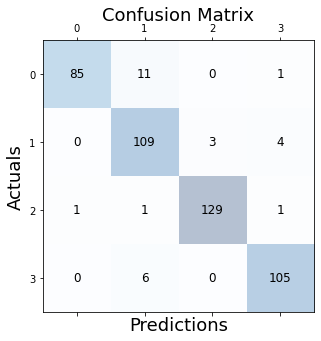

In [20]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.matshow(cm_train1, cmap=plt.cm.Blues, alpha=0.3)
for i in range(cm_train1.shape[0]):
    for j in range(cm_train1.shape[1]):
        ax.text(x=j, y=i,s=cm_train1[i, j], va='center', ha='center', size='large')
 
plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actuals', fontsize=18)
plt.title('Confusion Matrix', fontsize=18)
plt.show()

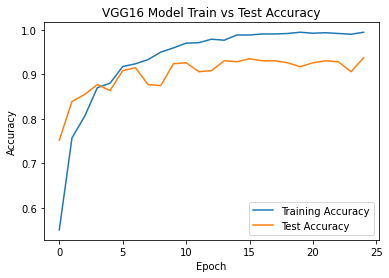

In [21]:
N = 25
plt.plot(np.arange(0, N), H1.history['accuracy'], label="Training Accuracy")
plt.plot(np.arange(0, N), H1.history['val_accuracy'], label="Test Accuracy")
plt.title('VGG16 Model Train vs Test Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()
#plt.savefig("acc_plot.png")

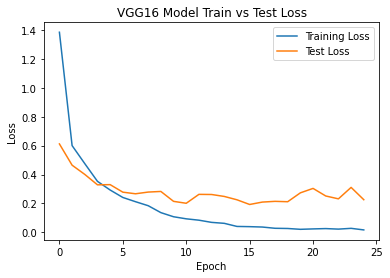

In [22]:
plt.plot(H1.history['loss'], label="Training Loss")
plt.plot(H1.history['val_loss'], label="Test Loss")
plt.title('VGG16 Model Train vs Test Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()
#plt.savefig("loss_plot.png")


***VGG-19*** **Model**

In [23]:
headmodel = VGG19(weights="imagenet", include_top=False,
                  input_tensor=Input(shape=(224, 224, 3)))

80150528/80134624 [==============================] - 0s 0us/step


In [24]:
model = headmodel.output
model = Dense(128, activation="relu")(model)
model = AveragePooling2D(pool_size=(2,2),strides=(1,1),padding='same')(model)
model = Dropout(0.5)(model)
model = GlobalAveragePooling2D()(model)
model = Flatten(name="flatten")(model)
model = Dense(512, activation="relu")(model)
model = Dropout(0.5)(model)
model = Dense(len(lb.classes_), activation="softmax")(model)
model2 = Model(inputs=headmodel.input, outputs=model)
for layer in headmodel.layers:
    layer.trainable = False

opt = Adam(learning_rate=0.001)
model2.compile(loss="categorical_crossentropy", optimizer=opt,
               metrics=["accuracy"])

In [25]:
H2 = model2.fit(
    trainAug.flow(trainX, trainY, batch_size=32),
    steps_per_epoch=len(trainX) // 32,
    validation_data=valAug.flow(testX, testY),
    validation_steps=len(testX) // 32,
    epochs=25,
    callbacks=[mc2])

Epoch 1/25
56/56 [==============================] - ETA: 0s - loss: 1.2495 - accuracy: 0.5598
Epoch 1: val_accuracy improved from -inf to 0.70982, saving model to model2.h5
56/56 [==============================] - 14s 238ms/step - loss: 1.2495 - accuracy: 0.5598 - val_loss: 0.6968 - val_accuracy: 0.7098
Epoch 2/25
56/56 [==============================] - ETA: 0s - loss: 0.6535 - accuracy: 0.7215
Epoch 2: val_accuracy improved from 0.70982 to 0.79241, saving model to model2.h5
56/56 [==============================] - 13s 233ms/step - loss: 0.6535 - accuracy: 0.7215 - val_loss: 0.5079 - val_accuracy: 0.7924
Epoch 3/25
56/56 [==============================] - ETA: 0s - loss: 0.4923 - accuracy: 0.7959
Epoch 3: val_accuracy improved from 0.79241 to 0.83259, saving model to model2.h5
56/56 [==============================] - 13s 232ms/step - loss: 0.4923 - accuracy: 0.7959 - val_loss: 0.4132 - val_accuracy: 0.8326
Epoch 4/25
56/56 [==============================] - ETA: 0s - loss: 0.3970 - ac

In [26]:
predictions2 = model2.predict(testX, batch_size=32)
print(classification_report(testY.argmax(axis=1),predictions2.argmax(axis=1), target_names=lb.classes_))


               precision    recall  f1-score   support

    asymmetry       0.90      0.89      0.89        97
calcification       0.84      0.84      0.84       116
    carcinoma       0.98      0.99      0.99       132
         mass       0.90      0.90      0.90       111

     accuracy                           0.91       456
    macro avg       0.91      0.91      0.91       456
 weighted avg       0.91      0.91      0.91       456



In [27]:
from sklearn.metrics import confusion_matrix
target_names = lb.classes_
cm_train2 = confusion_matrix(testY.argmax(axis=1),predictions2.argmax(axis=1))
print('Confusion Matrix')
print(cm_train2)

Confusion Matrix
[[ 86   7   0   4]
 [  9  98   2   7]
 [  0   1 131   0]
 [  1  10   0 100]]


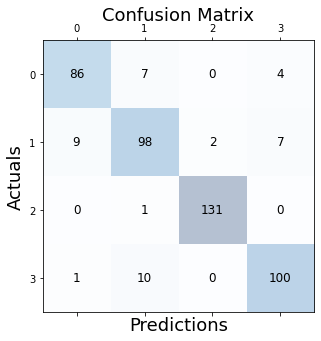

In [28]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.matshow(cm_train2, cmap=plt.cm.Blues, alpha=0.3)
for i in range(cm_train2.shape[0]):
    for j in range(cm_train2.shape[1]):
        ax.text(x=j, y=i,s=cm_train2[i, j], va='center', ha='center', size='large')
 
plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actuals', fontsize=18)
plt.title('Confusion Matrix', fontsize=18)
plt.show()

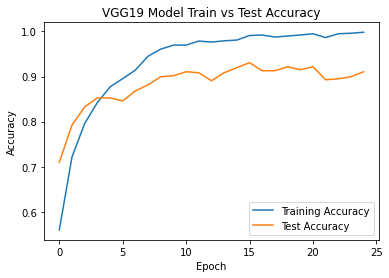

In [29]:
N = 25
plt.plot(np.arange(0, N), H2.history['accuracy'], label="Training Accuracy")
plt.plot(np.arange(0, N), H2.history['val_accuracy'], label="Test Accuracy")
plt.title('VGG19 Model Train vs Test Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()
#plt.savefig("acc_plot.png")

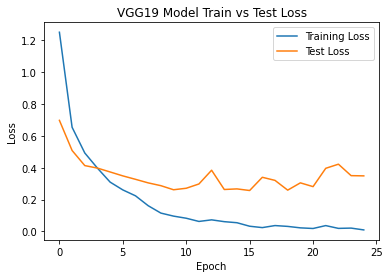

In [30]:
plt.plot(H2.history['loss'], label="Training Loss")
plt.plot(H2.history['val_loss'], label="Test Loss")
plt.title('VGG19 Model Train vs Test Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()
#plt.savefig("loss_plot.png")


***ResNet50 Model***

In [31]:
headmodel = ResNet50(weights="imagenet", include_top=False,
                  input_tensor=Input(shape=(224, 224, 3)))

94781440/94765736 [==============================] - 1s 0us/step


In [32]:
from keras.backend import batch_normalization
model = headmodel.output
model = Dense(128, activation="relu")(model)
model = AveragePooling2D(pool_size=(2,2),strides=(1,1),padding='same')(model)
model = Dropout(0.5)(model)
model = GlobalAveragePooling2D()(model)
model = Flatten(name="flatten")(model)
model = Dense(512, activation="relu")(model)
model = Dropout(0.6)(model)
model = Dense(len(lb.classes_), activation="softmax")(model)
model3 = Model(inputs=headmodel.input, outputs=model)
for layer in headmodel.layers:
    layer.trainable = False

opt = Adam(learning_rate=0.001)
model3.compile(loss="categorical_crossentropy", optimizer=opt,
               metrics=["accuracy"])

In [33]:
H3 = model3.fit(
    trainAug.flow(trainX, trainY, batch_size=32),
    steps_per_epoch=len(trainX) // 32,
    validation_data=valAug.flow(testX, testY),
    validation_steps=len(testX) // 32,
    epochs=25,
    callbacks=[mc3])

Epoch 1/25
56/56 [==============================] - ETA: 0s - loss: 0.9292 - accuracy: 0.6102
Epoch 1: val_accuracy improved from -inf to 0.76786, saving model to model3.h5
56/56 [==============================] - 15s 193ms/step - loss: 0.9292 - accuracy: 0.6102 - val_loss: 0.5588 - val_accuracy: 0.7679
Epoch 2/25
56/56 [==============================] - ETA: 0s - loss: 0.5213 - accuracy: 0.7987
Epoch 2: val_accuracy improved from 0.76786 to 0.83482, saving model to model3.h5
56/56 [==============================] - 8s 146ms/step - loss: 0.5213 - accuracy: 0.7987 - val_loss: 0.4079 - val_accuracy: 0.8348
Epoch 3/25
56/56 [==============================] - ETA: 0s - loss: 0.3877 - accuracy: 0.8456
Epoch 3: val_accuracy improved from 0.83482 to 0.89955, saving model to model3.h5
56/56 [==============================] - 8s 146ms/step - loss: 0.3877 - accuracy: 0.8456 - val_loss: 0.2841 - val_accuracy: 0.8996
Epoch 4/25
56/56 [==============================] - ETA: 0s - loss: 0.2870 - accu

In [34]:
predictions3 = model3.predict(testX, batch_size=32)
print(classification_report(testY.argmax(axis=1),predictions3.argmax(axis=1), target_names=lb.classes_))


               precision    recall  f1-score   support

    asymmetry       0.89      0.95      0.92        97
calcification       0.82      0.95      0.88       116
    carcinoma       0.99      0.98      0.99       132
         mass       1.00      0.79      0.88       111

     accuracy                           0.92       456
    macro avg       0.93      0.92      0.92       456
 weighted avg       0.93      0.92      0.92       456



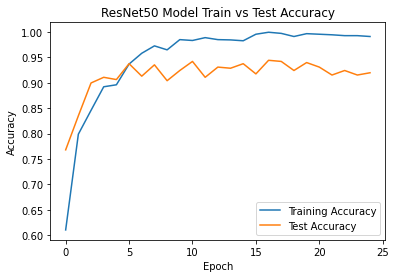

In [35]:
N = 25
plt.plot(np.arange(0, N), H3.history['accuracy'], label="Training Accuracy")
plt.plot(np.arange(0, N), H3.history['val_accuracy'], label="Test Accuracy")
plt.title('ResNet50 Model Train vs Test Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()
#plt.savefig("acc_plot.png")

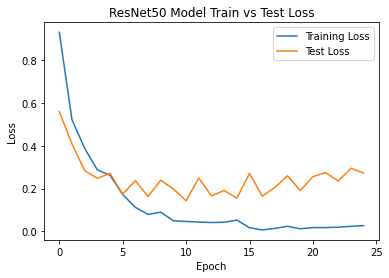

In [36]:
plt.plot(H3.history['loss'], label="Training Loss")
plt.plot(H3.history['val_loss'], label="Test Loss")
plt.title('ResNet50 Model Train vs Test Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()
#plt.savefig("loss_plot.png")


In [37]:
from sklearn.metrics import confusion_matrix
target_names = lb.classes_
cm_train3 = confusion_matrix(testY.argmax(axis=1),predictions3.argmax(axis=1))
print('Confusion Matrix')
print(cm_train3)


Confusion Matrix
[[ 92   5   0   0]
 [  5 110   1   0]
 [  0   2 130   0]
 [  6  17   0  88]]


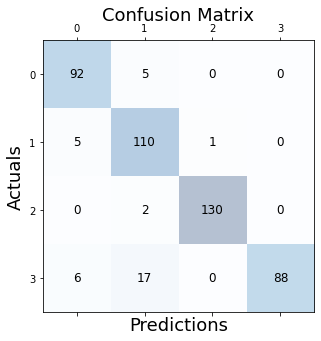

In [38]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.matshow(cm_train3, cmap=plt.cm.Blues, alpha=0.3)
for i in range(cm_train3.shape[0]):
    for j in range(cm_train3.shape[1]):
        ax.text(x=j, y=i,s=cm_train3[i, j], va='center', ha='center', size='large')
 
plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actuals', fontsize=18)
plt.title('Confusion Matrix', fontsize=18)
plt.show()

**Results**

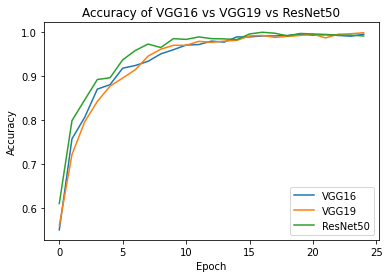

In [39]:
plt.plot(np.arange(0, N), H1.history['accuracy'], label="VGG16")
plt.plot(np.arange(0, N), H2.history['accuracy'], label="VGG19")
plt.plot(np.arange(0, N), H3.history['accuracy'], label="ResNet50")
plt.title('Accuracy of VGG16 vs VGG19 vs ResNet50')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()

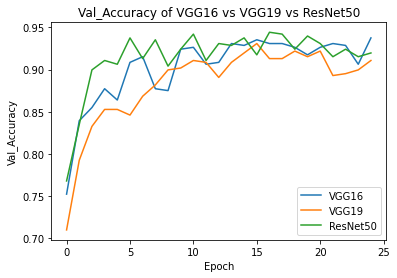

In [40]:
N = 25
plt.plot(np.arange(0, N), H1.history['val_accuracy'], label="VGG16")
plt.plot(np.arange(0, N), H2.history['val_accuracy'], label="VGG19")
plt.plot(np.arange(0, N), H3.history['val_accuracy'], label="ResNet50")
plt.title('Val_Accuracy of VGG16 vs VGG19 vs ResNet50')
plt.ylabel('Val_Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()

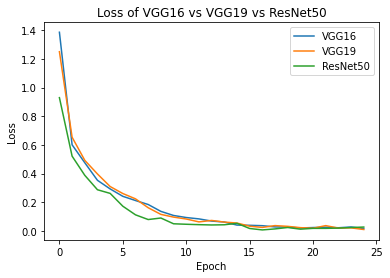

In [41]:
plt.plot(H1.history['loss'], label="VGG16")
plt.plot(H2.history['loss'], label="VGG19")
plt.plot(H3.history['loss'], label="ResNet50")
plt.title('Loss of VGG16 vs VGG19 vs ResNet50')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()


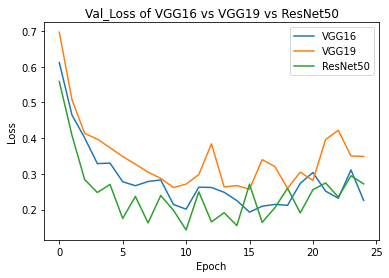

In [42]:
plt.plot(H1.history['val_loss'], label="VGG16")
plt.plot(H2.history['val_loss'], label="VGG19")
plt.plot(H3.history['val_loss'], label="ResNet50")
plt.title('Val_Loss of VGG16 vs VGG19 vs ResNet50')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

**Sequential Model**

In [43]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os,cv2
from IPython.display import Image
from keras.preprocessing import image
from keras import optimizers
from keras import layers,models
from keras.applications.imagenet_utils import preprocess_input
import matplotlib.pyplot as plt
from keras import regularizers
from keras.preprocessing.image import ImageDataGenerator


In [44]:
from tensorflow import keras
from keras.layers import *
from keras.models import *
from keras.preprocessing import image
from keras.layers.core import Dropout

img_size=224
batch_size=32

In [45]:
model=models.Sequential()
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(layers.MaxPool2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPool2D((2,2)))
model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPool2D((2,2)))
model.add(layers.Conv2D(512,(3,3),activation='relu'))
model.add(layers.Conv2D(512,(3,3),activation='relu'))
model.add(layers.MaxPool2D((2,2)))
model.add(Dense(512, activation="relu"))
model.add(GlobalAveragePooling2D())
model.add(Flatten(name="flatten")) 
model.add(Dense(512, activation="relu"))
model.add(Dense(len(lb.classes_), activation="softmax"))
opt = Adam(learning_rate=0.001)
model.compile(loss="categorical_crossentropy", optimizer=opt,
               metrics=["accuracy"])

In [ ]:
H = model.fit(trainAug.flow(trainX, trainY, batch_size=32),
    steps_per_epoch=len(trainX) // 32,
    validation_data=valAug.flow(testX, testY),
    validation_steps=len(testX) // 32,
    epochs=25)

Epoch 1/25
56/56 [==============================] - 13s 159ms/step - loss: 1.9276 - accuracy: 0.4016 - val_loss: 1.0803 - val_accuracy: 0.4643
Epoch 2/25
56/56 [==============================] - 7s 121ms/step - loss: 1.0801 - accuracy: 0.4659 - val_loss: 1.0301 - val_accuracy: 0.4665
Epoch 3/25
56/56 [==============================] - 7s 121ms/step - loss: 1.0177 - accuracy: 0.4855 - val_loss: 0.8969 - val_accuracy: 0.5246
Epoch 4/25
56/56 [==============================] - 7s 122ms/step - loss: 0.9019 - accuracy: 0.5520 - val_loss: 0.8270 - val_accuracy: 0.5759
Epoch 5/25
56/56 [==============================] - 7s 122ms/step - loss: 0.8759 - accuracy: 0.5587 - val_loss: 0.8092 - val_accuracy: 0.5871
Epoch 6/25
56/56 [==============================] - 7s 121ms/step - loss: 0.9577 - accuracy: 0.5459 - val_loss: 0.8699 - val_accuracy: 0.5938
Epoch 7/25
56/56 [==============================] - 7s 121ms/step - loss: 0.8231 - accuracy: 0.5889 - val_loss: 0.7975 - val_accuracy: 0.6049
Epoch

In [ ]:
predictions = model.predict(testX, batch_size=32)
print(classification_report(testY.argmax(axis=1),predictions.argmax(axis=1), target_names=lb.classes_))

In [ ]:
from sklearn.metrics import confusion_matrix
target_names = lb.classes_
cm_train = confusion_matrix(testY.argmax(axis=1),predictions.argmax(axis=1))
print('Confusion Matrix')
print(cm_train)

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.matshow(cm_train, cmap=plt.cm.Blues, alpha=0.3)
for i in range(cm_train.shape[0]):
    for j in range(cm_train.shape[1]):
        ax.text(x=j, y=i,s=cm_train[i, j], va='center', ha='center', size='large')
 
plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actuals', fontsize=18)
plt.title('Confusion Matrix', fontsize=18)
plt.show()

In [ ]:
N = 25
plt.plot(np.arange(0, N), H.history['accuracy'], label="Training Accuracy")
plt.plot(np.arange(0, N), H.history['val_accuracy'], label="Test Accuracy")
plt.title('CNN Model Train vs Test Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()
#plt.savefig("acc_plot.png")

In [ ]:
plt.plot(H.history['loss'], label="Training Loss")
plt.plot(H.history['val_loss'], label="Test Loss")
plt.title('CNN Model Train vs Test Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()
#plt.savefig("loss_plot.png")
